In [5]:
from data_load import load, load_qualtrics_data, merge_sync_qa_data, convert_data_time_series

# load synchrony data
synchrony_df = load()

# load qualtrics data
qa_df = load_qualtrics_data()

# merge qa data with sync data
merged_df = merge_sync_qa_data(synchrony_df, qa_df)
merged_df.head()

# convert data to time series
time_df = convert_data_time_series(synchrony_df, merged_df)

time_df.head()

c:\Users\mashf\OneDrive\Desktop\ps\data_load.py:187: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  time_df['cross_corr_ibi'] = time_df['cross_corr_ibi'].apply(lambda x: np.convolve(x, np.ones(window_length)/window_length, mode='valid'))
c:\Users\mashf\OneDrive\Desktop\ps\data_load.py:199: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.54736842 0.29473684 0.37894737 0.29473684 0.14736842 0.36842105
 0.25263158 0.21052632 0.04210526 0.12631579 0.04210526 0.73473684
 0.54736842 0.04210526 0.29473684 0.11578947 1.         0.25263158
 0.12631579 0.16842105 0.16842105 0.08421053 0.46947368 0.25263158
 0.16842105 0.08421053 0.08421053 0.02105263 0.28631579 0.16842105
 0.         0

,experiment,level,game_score,cross_corr_ibi,max_corr_ibi,Age,Gender,familiarity,Overall Collaboration,order,new_order,game_score_normalized,max_order,cross_corr_ibi_normalized,level_num,max_cross_corr_ibi_norm
0,Trial 01,asymmetric_advantages,280,24.211324,10.748068,"26, 26","Male, Male",1,4.5,0,0,<NA>,2527,0.011093,1,NaN
0,Trial 01,asymmetric_advantages,280,24.45502,10.748068,"26, 26","Male, Male",1,4.5,1,1,<NA>,2527,0.011458,1,NaN
0,Trial 01,asymmetric_advantages,280,24.698905,10.748068,"26, 26","Male, Male",1,4.5,2,2,<NA>,2527,0.011823,1,NaN
0,Trial 01,asymmetric_advantages,280,24.942978,10.748068,"26, 26","Male, Male",1,4.5,3,3,<NA>,2527,0.012189,1,NaN
0,Trial 01,asymmetric_advantages,280,25.187242,10.748068,"26, 26","Male, Male",1,4.5,4,4,<NA>,2527,0.012555,1,NaN


In [6]:
import seaborn as sns
import matplotlib as plt
experiments = time_df["experiment"].unique()

import matplotlib.pyplot as plt


# Scatterplot of max cross correlation and gamescore 


<Axes: xlabel='game_score_normalized', ylabel='max_cross_corr_ibi_norm'>

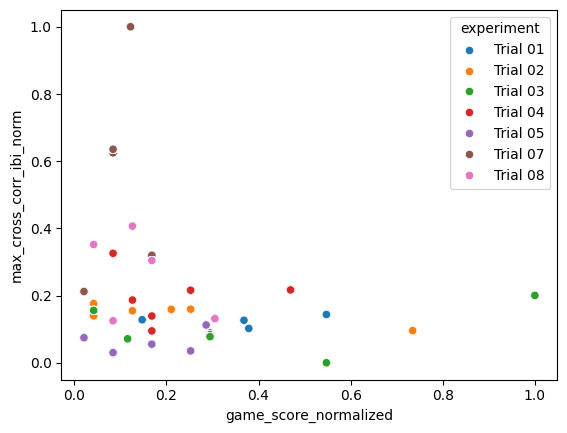

In [7]:

sns.scatterplot(x="game_score_normalized", y="max_cross_corr_ibi_norm", data=time_df, hue="experiment")


# Familiarity

In [8]:
from data_load import load, load_qualtrics_data, merge_sync_qa_data, familiarity_info

synchrony_df = load()

qa_df = load_qualtrics_data()

merged_df = merge_sync_qa_data(synchrony_df, qa_df)
# merged_df.()


C:\Users\mashf\AppData\Local\Temp\ipykernel_19024\560834517.py:18: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='familiarity', y='max_corr_ibi_normalized', data=grouped_df, ci=None, color='lightblue')
C:\Users\mashf\AppData\Local\Temp\ipykernel_19024\560834517.py:26: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='familiarity', y='game_score_normalized', data=grouped_df, ci=None, color='lightblue')


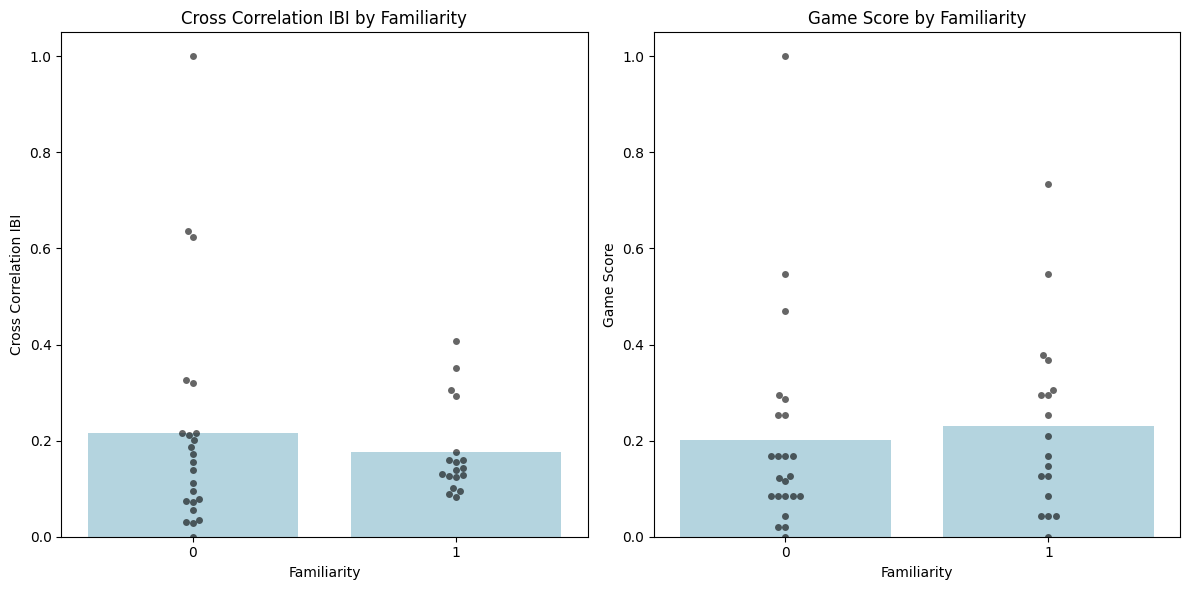

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming time_df is already loaded and contains the necessary columns

# Group by familiarity and calculate mean values
grouped_df = merged_df.groupby('familiarity').agg({
    'max_corr_ibi_normalized': 'mean',
    'game_score_normalized': 'mean'
}).reset_index()

# Plotting the patterns
plt.figure(figsize=(12, 6))

# Bar plot and swarm plot for max_corr_ibi_normalized
plt.subplot(1, 2, 1)
sns.barplot(x='familiarity', y='max_corr_ibi_normalized', data=grouped_df, ci=None, color='lightblue')
sns.swarmplot(x='familiarity', y='max_corr_ibi_normalized', data=merged_df, color='black', alpha=0.6)
plt.title('Cross Correlation IBI by Familiarity')
plt.xlabel('Familiarity')
plt.ylabel('Cross Correlation IBI')

# Bar plot and swarm plot for game_score_normalized
plt.subplot(1, 2, 2)
sns.barplot(x='familiarity', y='game_score_normalized', data=grouped_df, ci=None, color='lightblue')
sns.swarmplot(x='familiarity', y='game_score_normalized', data=merged_df, color='black', alpha=0.6)
plt.title('Game Score by Familiarity')
plt.xlabel('Familiarity')
plt.ylabel('Game Score')

plt.tight_layout()
plt.show()